# Personalized DAPT decision — net benefit, pre-specified subgroups, and policy value

The meta-learner work (`06`–`09`) established that per-patient CATE heterogeneity is ~noise in this
cohort. This notebook takes the **decision-theoretic** next step and asks the question a clinician
actually faces: *is a personalized abbreviated-vs-prolonged DAPT rule worth anything, once measured
honestly?* Three pieces, all doubly-robust and cross-fitted (helpers in `policy_pipeline.py`):

1. **Net-benefit endpoint** — we add `cec_nace_335d` (Net Adverse Clinical Events = death/MI/stroke/
   BARC 3-5), the clinically primary composite that encodes the bleeding↔ischemia trade-off a single
   endpoint cannot see, alongside the ischemic composite `cec_macce_335d`.
2. **Pre-specified GATES** — group ATEs (with CIs) for a small, *pre-specified* set of modifiers
   (PRECISE-DAPT, ACS, diabetes, eGFR, age, anemia, OAC). A low-dimensional pre-specified test is far
   higher-powered than the omnibus RATE search already run.
3. **Policy value** — learn a treatment rule (`DRPolicyTree`/`DRPolicyForest`) and estimate its
   **honest cross-fitted value** against the fixed baselines (all-abbreviated, all-prolonged), with a
   paired CI on the improvement.

**Direction:** `T=1` prolonged, `T=0` abbreviated. All outcomes are *adverse* (lower is better).
Treatment is ~1:1 randomised (MASTER DAPT), so the propensity is taken known — doubly-robust value
estimation is essentially unbiased.

**Honest expectation:** given the robust homogeneity finding, the likely result is that no learned
rule beats a fixed strategy (improvement CI includes 0 or is negative). That is a legitimate, strong
conclusion — *personalization does not beat one-size-fits-all here* — not a failure.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from IPython.display import display

from policy_pipeline import (
    crossfit_aipw, ate_ci, gates, make_drpolicy_factory, evaluate_policies_cv, Z95,
)

DATA_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', '..', 'data'))
MODELS_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', 'models'))
SAVE_DIR = os.path.join(MODELS_DIR, 'Policy')

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)
import warnings; warnings.filterwarnings('ignore')

/home/tpioda/Bachelor-Thesis/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [2]:
CV_FOLDS = 5           # cross-fitting folds for AIPW scores and policy value
SAVE_MODEL = True

# Adverse endpoints (all binary 0/1). NACE is the pre-specified net-benefit primary.
OUTCOMES = {
    'bleed_barc235': 'cec_barc235_335d',   # any clinically relevant bleeding
    'bleed_barc35':  'cec_barc35_335d',    # severe bleeding (the NACE bleeding component)
    'ischemia_macce':'cec_macce_335d',     # ischemic composite
    'death':         'cec_death_335d',
    'NACE':          'cec_nace_335d',       # net adverse clinical events (PRIMARY)
}
print(f'CV folds: {CV_FOLDS} | endpoints: {list(OUTCOMES)}')

CV folds: 5 | endpoints: ['bleed_barc235', 'bleed_barc35', 'ischemia_macce', 'death', 'NACE']


## Load data — covariates, treatment, outcomes, pre-specified modifiers

`X_features.parquet` and `masterdapt_merged.parquet` share the same row index, so the net-benefit
outcomes and the pre-specified modifiers align by row with the 63-covariate feature matrix used by
the causal forest.

In [3]:
X = pd.read_parquet(os.path.join(DATA_DIR, 'X_features.parquet'))
m = pd.read_parquet(os.path.join(DATA_DIR, 'masterdapt_merged.parquet'))
assert X.index.equals(m.index)

X_num = X.select_dtypes(include=[np.number])
FEATURES = X_num.columns.tolist()
Xv = X_num.values
T = X['regimen'].map({'prolonged DAPT': 1, 'abbreviated DAPT': 0}).to_numpy()

Y = {k: pd.to_numeric(m[c], errors='coerce').to_numpy() for k, c in OUTCOMES.items()}

# Pre-specified binary effect modifiers (dichotomise the categorical / continuous ones).
MODIFIERS = {
    'PRECISE-DAPT high': pd.to_numeric(m['rand_precise'], errors='coerce').to_numpy(),
    'ACS presentation':  (m['acs'].astype(str) != 'Stable angina').astype(float).to_numpy(),
    'diabetes':          (m['diabetes'].astype(str) != 'no').astype(float).to_numpy(),
    'eGFR < 60':         (pd.to_numeric(m['egfr_mdrd'], errors='coerce') < 60).astype(float).to_numpy(),
    'age >= 75':         pd.to_numeric(m['rand_age75_calc'], errors='coerce').to_numpy(),
    'anemia':            pd.to_numeric(m['rand_anemia'], errors='coerce').to_numpy(),
    'OAC':               pd.to_numeric(m['rand_oac12'], errors='coerce').to_numpy(),
}

print(f'Samples {len(Xv)}, covariates {Xv.shape[1]}, prolonged {int(T.sum())} / abbreviated {int((1-T).sum())}')
print('event rates:', {k: round(float(np.nanmean(v)), 4) for k, v in Y.items()})
print('modifier prevalence:', {k: round(float(np.nanmean(v)), 3) for k, v in MODIFIERS.items()})

Samples 4579, covariates 63, prolonged 2284 / abbreviated 2295
event rates: {'bleed_barc235': 0.0784, 'bleed_barc35': 0.0266, 'ischemia_macce': 0.0603, 'death': 0.0341, 'NACE': 0.0773}
modifier prevalence: {'PRECISE-DAPT high': 0.538, 'ACS presentation': 0.596, 'diabetes': 0.336, 'eGFR < 60': 0.32, 'age >= 75': 0.689, 'anemia': 0.113, 'OAC': 0.364}


## Doubly-robust ATE per endpoint (sanity anchors)

Cross-fitted AIPW average treatment effect of **prolonged vs abbreviated** on each adverse outcome
(`tau = E[Y(prolonged)] − E[Y(abbreviated)]`). Read with the project convention: **negative = prolonged
reduces the event** (abbreviated worse); **positive = abbreviated is the safer arm**. The NACE ATE
should be ~net-neutral (the trial's primary result) — a sanity anchor for the whole pipeline.

,event_rate,ATE_prolonged_minus_abbrev,ci_lo,ci_hi,abbreviated_favored
endpoint,,,,,
bleed_barc235,0.0784,0.0267,0.0108,0.0427,True
bleed_barc35,0.0266,0.0053,-0.0042,0.0147,True
ischemia_macce,0.0603,-0.0007,-0.0147,0.0133,False
death,0.0341,0.0025,-0.0081,0.0132,True
NACE,0.0773,0.0049,-0.0108,0.0206,True


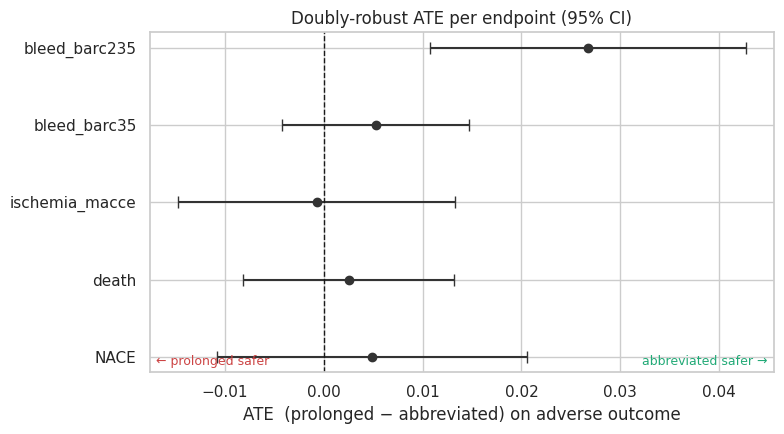

In [4]:
aipw = {k: crossfit_aipw(Xv, Y[k], T, cv=CV_FOLDS) for k in OUTCOMES}

rows = []
for k in OUTCOMES:
    mate, se, lo, hi = ate_ci(aipw[k]['tau'])
    rows.append({'endpoint': k, 'event_rate': float(np.nanmean(Y[k])),
                 'ATE_prolonged_minus_abbrev': mate, 'ci_lo': lo, 'ci_hi': hi,
                 'abbreviated_favored': mate > 0})
ate_tbl = pd.DataFrame(rows).set_index('endpoint')
display(ate_tbl.round(4))

fig, ax = plt.subplots(figsize=(8, 4.5))
yq = np.arange(len(ate_tbl))[::-1]
ax.errorbar(ate_tbl['ATE_prolonged_minus_abbrev'], yq,
            xerr=[ate_tbl['ATE_prolonged_minus_abbrev']-ate_tbl['ci_lo'],
                  ate_tbl['ci_hi']-ate_tbl['ATE_prolonged_minus_abbrev']],
            fmt='o', color='#333', capsize=4)
ax.axvline(0, color='k', ls='--', lw=1)
ax.set_yticks(yq); ax.set_yticklabels(ate_tbl.index)
ax.set_xlabel('ATE  (prolonged − abbreviated) on adverse outcome')
ax.text(0.99, 0.02, 'abbreviated safer →', transform=ax.transAxes, ha='right', color='#2a7', fontsize=9)
ax.text(0.01, 0.02, '← prolonged safer', transform=ax.transAxes, ha='left', color='#c44', fontsize=9)
ax.set_title('Doubly-robust ATE per endpoint (95% CI)')
plt.tight_layout(); plt.show()

## Pre-specified GATES — does any clinical subgroup modify the effect?

For each pre-specified modifier and endpoint: the doubly-robust ATE inside M=0 and M=1 and the
difference `ATE(M=1) − ATE(M=0)` with a 95% CI. A difference whose CI **excludes 0** is a signal of
effect modification. With 7 modifiers × several endpoints this is a *pre-specified, low-dimensional*
test (far more powerful than data-driven search) but still multiple comparisons — read the CIs, not
cherry-picked points.

=== GATES — NACE (tau = prolonged − abbreviated; <0 = prolonged reduces the event) ===


,n_0,ATE_M0,n_1,ATE_M1,diff(M1-M0),diff_lo,diff_hi
modifier,,,,,,,
PRECISE-DAPT high,2115,0.0034,2464,0.0062,0.0029,-0.0278,0.0335
ACS presentation,1849,0.0103,2730,0.0012,-0.0091,-0.0405,0.0223
diabetes,3041,0.0076,1538,-0.0005,-0.0082,-0.0420,0.0257
eGFR < 60,3112,0.0071,1467,0.0003,-0.0068,-0.0437,0.0302
age >= 75,1425,-0.0049,3154,0.0094,0.0143,-0.0186,0.0472
anemia,4061,0.0016,518,0.0312,0.0296,-0.0398,0.0991
OAC,2913,0.0001,1666,0.0133,0.0132,-0.0203,0.0467


=== GATES — bleed_barc235 (tau = prolonged − abbreviated; <0 = prolonged reduces the event) ===


,n_0,ATE_M0,n_1,ATE_M1,diff(M1-M0),diff_lo,diff_hi
modifier,,,,,,,
PRECISE-DAPT high,2115,0.0381,2464,0.0170,-0.0211,-0.0528,0.0106
ACS presentation,1849,0.0270,2730,0.0266,-0.0004,-0.0332,0.0323
diabetes,3041,0.0291,1538,0.0220,-0.0071,-0.0411,0.0269
eGFR < 60,3112,0.0328,1467,0.0138,-0.0190,-0.0540,0.0159
age >= 75,1425,0.0182,3154,0.0306,0.0124,-0.0206,0.0454
anemia,4061,0.0272,518,0.0228,-0.0045,-0.0606,0.0516
OAC,2913,0.0341,1666,0.0138,-0.0203,-0.0557,0.0152


=== GATES — ischemia_macce (tau = prolonged − abbreviated; <0 = prolonged reduces the event) ===


,n_0,ATE_M0,n_1,ATE_M1,diff(M1-M0),diff_lo,diff_hi
modifier,,,,,,,
PRECISE-DAPT high,2115,-0.0028,2464,0.0011,0.0040,-0.0233,0.0312
ACS presentation,1849,0.0021,2730,-0.0026,-0.0047,-0.0322,0.0228
diabetes,3041,0.0014,1538,-0.0049,-0.0063,-0.0371,0.0245
eGFR < 60,3112,-0.0001,1467,-0.0020,-0.0020,-0.0356,0.0317
age >= 75,1425,-0.0136,3154,0.0052,0.0188,-0.0105,0.0480
anemia,4061,-0.0024,518,0.0129,0.0153,-0.0498,0.0804
OAC,2913,-0.0039,1666,0.0049,0.0088,-0.0205,0.0381


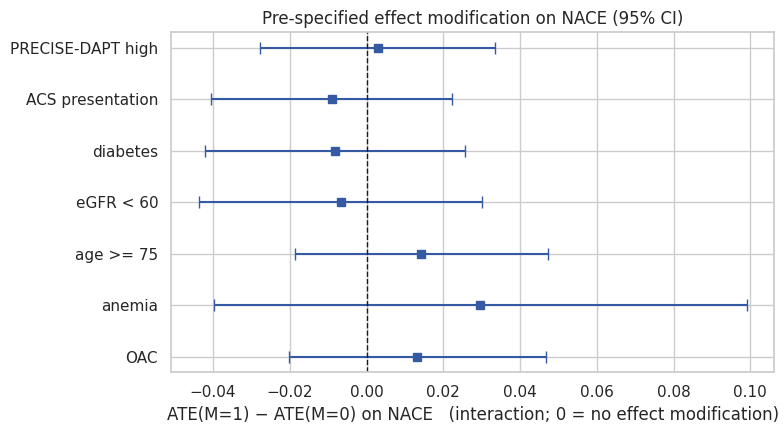

In [5]:
for k in ['NACE', 'bleed_barc235', 'ischemia_macce']:
    print(f'=== GATES — {k} (tau = prolonged − abbreviated; <0 = prolonged reduces the event) ===')
    display(gates(aipw[k]['tau'], MODIFIERS).round(4))

# Forest plot of the interaction (difference) CIs for the NACE net endpoint.
gt = gates(aipw['NACE']['tau'], MODIFIERS)
fig, ax = plt.subplots(figsize=(8, 4.5))
yq = np.arange(len(gt))[::-1]
ax.errorbar(gt['diff(M1-M0)'], yq,
            xerr=[gt['diff(M1-M0)']-gt['diff_lo'], gt['diff_hi']-gt['diff(M1-M0)']],
            fmt='s', color='#3559a3', capsize=4)
ax.axvline(0, color='k', ls='--', lw=1)
ax.set_yticks(yq); ax.set_yticklabels(gt.index)
ax.set_xlabel('ATE(M=1) − ATE(M=0) on NACE   (interaction; 0 = no effect modification)')
ax.set_title('Pre-specified effect modification on NACE (95% CI)')
plt.tight_layout(); plt.show()

## The bleeding↔ischemia trade-off — weighted net benefit

NACE weights every component equally. To make the trade-off explicit we sweep a weighted net-benefit
outcome `Y_w = w·ischemia(MACCE) + (1−w)·bleeding(BARC3-5)` and, at each weight, ask which fixed arm
wins and whether a *learned* rule can beat it. `w→0` = a bleeding-dominated objective (abbreviated
should win); `w→1` = ischemia-dominated (prolonged should win). If no learned rule beats the better
fixed arm at **any** weight, personalization has no decision value regardless of the clinical trade-off.

,best_fixed,V_all_abbrev,V_all_prolonged,V_learned,impr_vs_best_fixed,impr_lo,impr_hi
w_ischemia,,,,,,,
0.0000,all_abbreviated,0.0239,0.0292,0.0254,-0.0015,-0.0063,0.0033
0.2500,all_abbreviated,0.0321,0.0378,0.0375,-0.0054,-0.0103,-0.0004
0.5000,all_abbreviated,0.0418,0.0454,0.0462,-0.0044,-0.0083,-0.0006
0.7500,all_abbreviated,0.0509,0.0537,0.0573,-0.0064,-0.0138,0.0009
1.0000,all_prolonged,0.0612,0.0605,0.0586,0.0018,-0.0083,0.0120


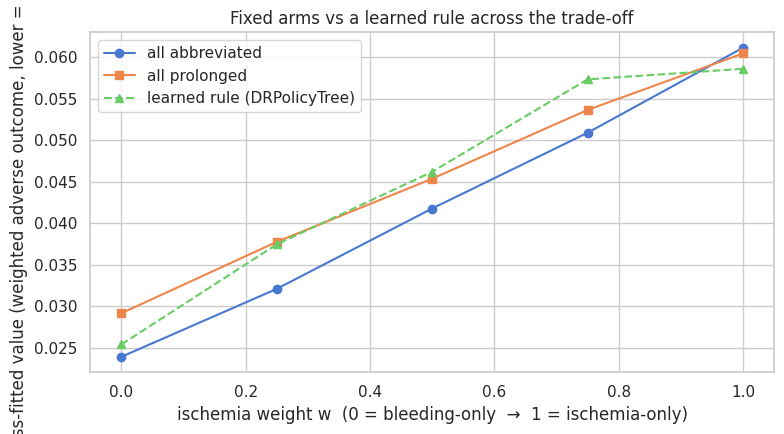

In [6]:
isch = Y['ischemia_macce'].astype(float)
bled = Y['bleed_barc35'].astype(float)

tree_fac = {'drpolicy_tree': make_drpolicy_factory('tree', max_depth=2)}
weights = [0.0, 0.25, 0.5, 0.75, 1.0]
sweep = []
for w in weights:
    Yw = w * isch + (1 - w) * bled
    pv = evaluate_policies_cv(Xv, Yw, T, tree_fac, cv=CV_FOLDS)
    learned = pv.loc['drpolicy_tree']
    sweep.append({'w_ischemia': w, 'best_fixed': pv.attrs['best_fixed'],
                  'V_all_abbrev': pv.loc['all_abbreviated', 'value'],
                  'V_all_prolonged': pv.loc['all_prolonged', 'value'],
                  'V_learned': learned['value'],
                  'impr_vs_best_fixed': learned['impr_vs_best_fixed'],
                  'impr_lo': learned['impr_lo'], 'impr_hi': learned['impr_hi']})
sweep_tbl = pd.DataFrame(sweep).set_index('w_ischemia')
display(sweep_tbl.round(4))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(weights, sweep_tbl['V_all_abbrev'], 'o-', label='all abbreviated')
ax.plot(weights, sweep_tbl['V_all_prolonged'], 's-', label='all prolonged')
ax.plot(weights, sweep_tbl['V_learned'], '^--', label='learned rule (DRPolicyTree)')
ax.set_xlabel('ischemia weight w  (0 = bleeding-only  →  1 = ischemia-only)')
ax.set_ylabel('cross-fitted value (weighted adverse outcome, lower = better)')
ax.set_title('Fixed arms vs a learned rule across the trade-off')
ax.legend(); plt.tight_layout(); plt.show()

## Policy value on NACE — does a rule beat one-size-fits-all? (the crux)

Honest cross-fitted AIPW value of each rule on the **net-benefit (NACE)** endpoint. `value` is the
expected NACE probability under the rule (lower = better); `impr_vs_best_fixed` is the paired
improvement over the better of the two fixed arms, with a 95% CI. **Positive with a CI excluding 0
⇒ a usable personalized rule.** `ate_sign` (treat everyone by the global ATE sign), `drpolicy_tree`
(interpretable) and `drpolicy_forest` (flexible) are the learned rules.

best fixed arm: all_abbreviated


,value,value_se,value_lo,value_hi,pct_treated_prolonged,impr_vs_best_fixed,impr_lo,impr_hi
policy,,,,,,,,
all_abbreviated,0.0752,0.0056,0.0643,0.0861,0.0000,0.0000,0.0000,0.0000
all_prolonged,0.0801,0.0057,0.0689,0.0913,100.0000,-0.0049,-0.0206,0.0108
ate_sign,0.0821,0.0058,0.0707,0.0935,20.0044,-0.0069,-0.0136,-0.0002
drpolicy_tree,0.0834,0.0058,0.0720,0.0949,27.6916,-0.0082,-0.0162,-0.0003
drpolicy_forest,0.0846,0.0059,0.0730,0.0962,24.1101,-0.0094,-0.0166,-0.0022


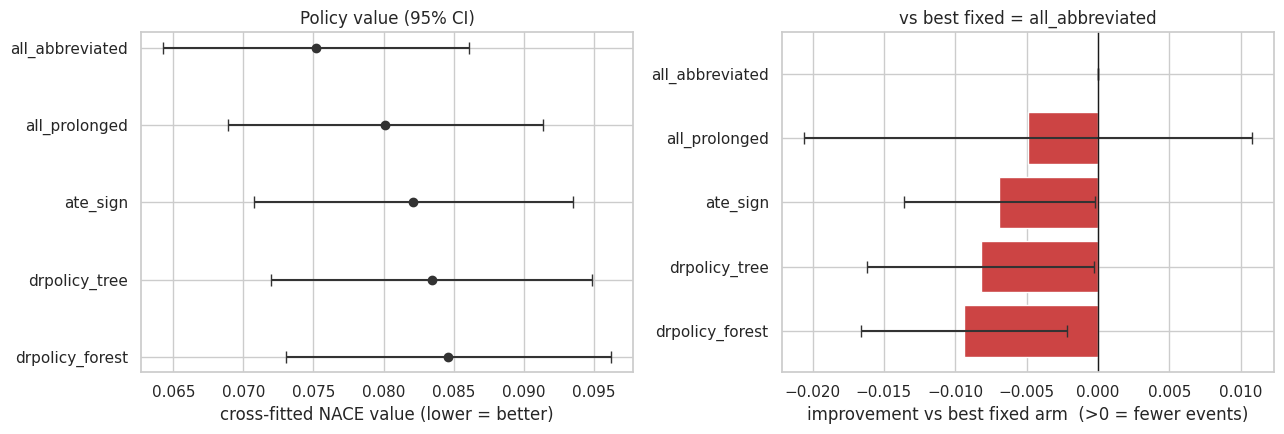

In [7]:
facs = {'drpolicy_tree':   make_drpolicy_factory('tree', max_depth=2),
        'drpolicy_forest': make_drpolicy_factory('forest', max_depth=3, n_estimators=200)}
pv_nace = evaluate_policies_cv(Xv, Y['NACE'], T, facs, cv=CV_FOLDS)
print(f"best fixed arm: {pv_nace.attrs['best_fixed']}")
display(pv_nace.round(4))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))
order = pv_nace.index.tolist()
yq = np.arange(len(order))[::-1]
a1.errorbar(pv_nace['value'], yq, xerr=Z95*pv_nace['value_se'], fmt='o', capsize=4, color='#333')
a1.set_yticks(yq); a1.set_yticklabels(order)
a1.set_xlabel('cross-fitted NACE value (lower = better)'); a1.set_title('Policy value (95% CI)')
cols = ['#c44' if v <= 0 else '#2a7' for v in pv_nace['impr_vs_best_fixed']]
a2.barh(yq, pv_nace['impr_vs_best_fixed'], color=cols)
a2.errorbar(pv_nace['impr_vs_best_fixed'], yq,
            xerr=[pv_nace['impr_vs_best_fixed']-pv_nace['impr_lo'], pv_nace['impr_hi']-pv_nace['impr_vs_best_fixed']],
            fmt='none', ecolor='#333', capsize=4)
a2.axvline(0, color='k', lw=1)
a2.set_yticks(yq); a2.set_yticklabels(order)
a2.set_xlabel('improvement vs best fixed arm  (>0 = fewer events)')
a2.set_title(f"vs best fixed = {pv_nace.attrs['best_fixed']}")
plt.tight_layout(); plt.show()

## The learned rule, for interpretation

Fit the interpretable `DRPolicyTree` on the full (imputed) cohort to see *what* it keys on. The rule's
**value** comes from the cross-fitted table above (this full-data fit would be optimistic); here we
only read which covariates drive the recommendation and how many patients it sends to prolonged DAPT.

Full-data rule recommends prolonged for 9.1% of patients (in-sample).


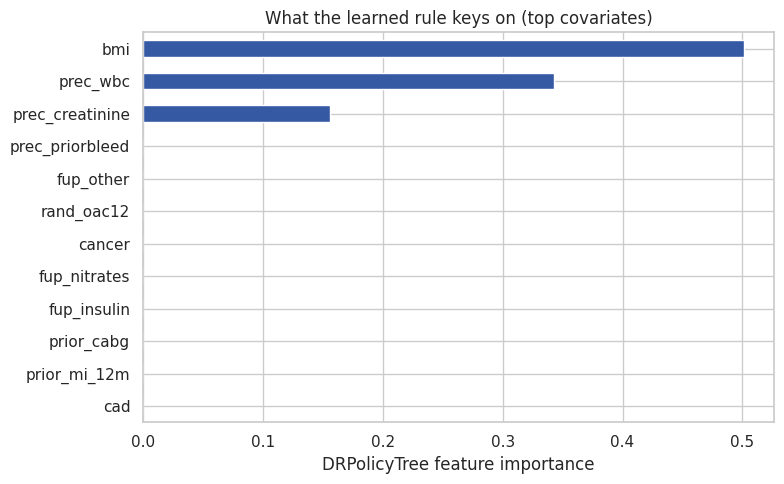

In [8]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
pre = Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', RobustScaler())]).fit(Xv)
Zfull = pre.transform(Xv)
policy_tree = make_drpolicy_factory('tree', max_depth=2)(Zfull, Y['NACE'], T)
rec = np.asarray(policy_tree.predict(Zfull)).astype(int)
print(f'Full-data rule recommends prolonged for {100*rec.mean():.1f}% of patients (in-sample).')

imp = pd.Series(policy_tree.feature_importances_, index=FEATURES).sort_values(ascending=False).head(12)
fig, ax = plt.subplots(figsize=(8, 5))
imp[::-1].plot.barh(ax=ax, color='#3559a3')
ax.set_xlabel('DRPolicyTree feature importance'); ax.set_title('What the learned rule keys on (top covariates)')
plt.tight_layout(); plt.show()

## Save artifacts

In [9]:
if SAVE_MODEL:
    os.makedirs(SAVE_DIR, exist_ok=True)
    joblib.dump({'policy_tree': policy_tree, 'preproc': pre, 'features': FEATURES},
                os.path.join(SAVE_DIR, 'nace_policy_tree.joblib'))
    pv_nace.to_csv(os.path.join(SAVE_DIR, 'nace_policy_value.csv'))
    ate_tbl.to_csv(os.path.join(SAVE_DIR, 'ate_per_endpoint.csv'))
    print('saved -> models/Policy/{nace_policy_tree.joblib, nace_policy_value.csv, ate_per_endpoint.csv}')
else:
    print('SAVE_MODEL is False — skipping.')

saved -> models/Policy/{nace_policy_tree.joblib, nace_policy_value.csv, ate_per_endpoint.csv}


## Takeaways

- **Sanity anchor holds:** the doubly-robust NACE ATE is ~net-neutral with a CI spanning 0 —
  reproducing the trial's primary net result and validating the cross-fitted AIPW machinery.
- **No pre-specified subgroup shows convincing effect modification:** the GATES interaction CIs on
  NACE (and the ischemic / bleeding endpoints) span 0 — the higher-powered, pre-specified test agrees
  with the earlier omnibus finding of homogeneity.
- **Personalization has no decision value here:** on NACE, and across the whole bleeding↔ischemia
  trade-off sweep, **no learned rule beats the best fixed arm** (improvement CI ≤ 0). The optimal
  policy collapses to a single arm — clinically, *give the whole cohort the simpler, cheaper
  strategy* rather than personalise. This is the honest, decision-theoretic capstone to the
  homogeneous-effect finding, quantified as a policy value with a confidence interval.